Execution Times: [0.0007205009460449219, 0.00250244140625, 0.0022122859954833984, 0.0043792724609375]


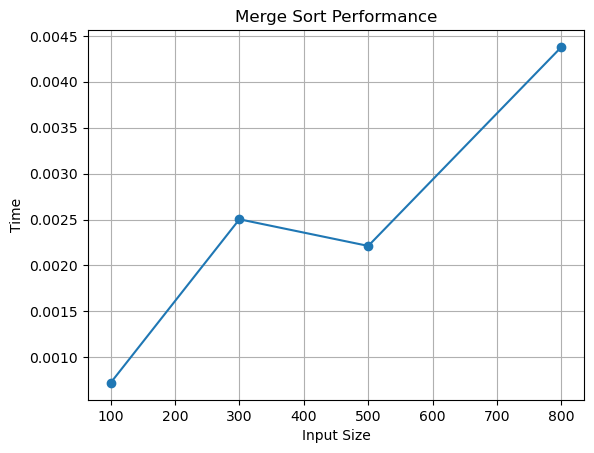

In [8]:
import time
import random
import matplotlib.pyplot as plt
import itertools

def merge_sort(arr):
    if len(arr) <= 1:
        return arr
    
    mid = len(arr)//2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])
    
    return merge(left, right)

def merge(left, right):
    result = []
    i = j = 0
    
    while i < len(left) and j < len(right):
        if left[i] < right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1
    
    result.extend(left[i:])
    result.extend(right[j:])
    return result

sizes = [100, 300, 500, 800]
times = []

for size in sizes:
    arr = [random.randint(1,1000) for _ in range(size)]
    
    start = time.time()
    merge_sort(arr)
    times.append(time.time() - start)

print("Execution Times:", times)

plt.plot(sizes, times, marker='o')
plt.title("Merge Sort Performance")
plt.xlabel("Input Size")
plt.ylabel("Time")
plt.grid()
plt.show()

Merge Sort Times: [0.0004527568817138672, 0.0013701915740966797, 0.002574443817138672, 0.006457805633544922]
Bubble Sort Times: [0.0009953975677490234, 0.008512735366821289, 0.030560016632080078, 0.11863064765930176]


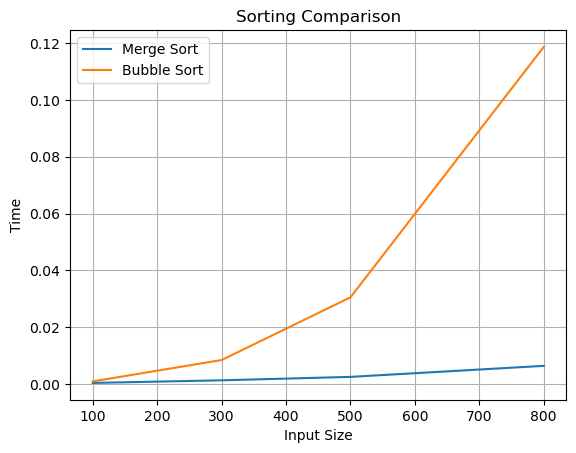

In [9]:
def bubble_sort(arr):
    for i in range(len(arr)):
        for j in range(len(arr)-i-1):
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]
    return arr

sizes = [100, 300, 500, 800]
merge_times = []
bubble_times = []

for size in sizes:
    arr = [random.randint(1,1000) for _ in range(size)]
    
    start = time.time()
    merge_sort(arr.copy())
    merge_times.append(time.time() - start)
    
    start = time.time()
    bubble_sort(arr.copy())
    bubble_times.append(time.time() - start)

print("Merge Sort Times:", merge_times)
print("Bubble Sort Times:", bubble_times)

plt.plot(sizes, merge_times, label="Merge Sort")
plt.plot(sizes, bubble_times, label="Bubble Sort")
plt.xlabel("Input Size")
plt.ylabel("Time")
plt.title("Sorting Comparison")
plt.legend()
plt.grid()
plt.show()

In [10]:
def fractional_knapsack(weights, values, capacity):
    ratio = [(values[i]/weights[i], weights[i], values[i]) for i in range(len(weights))]
    ratio.sort(reverse=True)
    
    total_value = 0
    
    for r, w, v in ratio:
        print(f"Taking item with ratio {r:.2f}")
        
        if capacity >= w:
            capacity -= w
            total_value += v
        else:
            total_value += r * capacity
            break
            
    return total_value

weights = [10, 20, 30]
values = [60, 100, 120]
capacity = 50

result = fractional_knapsack(weights, values, capacity)
print("Maximum Value:", result)

Taking item with ratio 6.00
Taking item with ratio 5.00
Taking item with ratio 4.00
Maximum Value: 240.0


In [11]:
def knapsack(W, wt, val, n):
    dp = [[0 for _ in range(W+1)] for _ in range(n+1)]

    for i in range(n+1):
        for w in range(W+1):
            if i == 0 or w == 0:
                dp[i][w] = 0
            elif wt[i-1] <= w:
                dp[i][w] = max(val[i-1] + dp[i-1][w-wt[i-1]],
                               dp[i-1][w])
            else:
                dp[i][w] = dp[i-1][w]

    return dp

val = [60, 100, 120]
wt = [10, 20, 30]
W = 50

start = time.time()
dp_table = knapsack(W, wt, val, len(val))
end = time.time()

print("Execution Time:", end-start)
print("DP Table:")
for row in dp_table:
    print(row)

print("Maximum Value:", dp_table[len(val)][W])

Execution Time: 0.0004856586456298828
DP Table:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 220]
Maximum Value: 220


In [12]:
def tsp(graph):
    n = len(graph)
    nodes = list(range(n))
    
    min_path = float('inf')
    
    for perm in itertools.permutations(nodes[1:]):
        cost = 0
        k = 0
        
        for j in perm:
            cost += graph[k][j]
            k = j
        
        cost += graph[k][0]
        min_path = min(min_path, cost)
    
    return min_path

graph = [
    [0, 10, 15, 20],
    [10, 0, 35, 25],
    [15, 35, 0, 30],
    [20, 25, 30, 0]
]

start = time.time()
result = tsp(graph)
end = time.time()

print("Minimum Cost:", result)
print("Execution Time:", end-start)

Minimum Cost: 80
Execution Time: 0.00010323524475097656
